In [1]:
import matplotlib.pyplot as plt
from glob import glob
import numpy as np
from matplotlib.gridspec import GridSpec
import cmocean.cm as cm
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cft
import scipy.io as sio
from tqdm import tqdm
import seawater as sw
import matplotlib.ticker as mticker
import matplotlib.patheffects as mpe

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/sitecustomize.py:72: UserWarning: The seawater library is deprecated! Please use gsw instead.
  mod = _real_import(name, globals, locals, fromlist, level)


In [2]:
# Set figures properties
import seaborn as sns
# sns.set_style('darkgrid')
# sns.reset_orig()
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

In [3]:
def mod_grad(Ln, Lt, field):
    ''' Compute the module of a gradient in F(x,y)
    ===========================================================================
    Input :
    -> LON: [m,n]
    -> LAT: [m,n]
    -> field: [m,n]
    ===========================================================================
    Output:
    -> |$\nabla( F[x,y] )$|
    ===========================================================================
    Felipe Vilela da Silva @ IMAS, UTas, AU
    27-11-2020
    '''
    # LON, LAT = np.meshgrid(Ln, Lt)
    
    [trash,dlonx]  = np.gradient(LON)
    dx = dlonx*np.cos(LAT*np.pi/180)*111195.
    [dlaty,trash] = np.gradient(LAT)
    dy = dlaty*111195.

    [dfy,dfx] = np.gradient(field)
    dfdx, dfdy = dfx/dx, dfy/dy
    
    _f_ = np.sqrt((dfdx)**2 + (dfdy)**2)
    
    return _f_

In [4]:
def argnear(dat,val,how_many=1):
    dif = np.abs(dat-val)
    idx = np.argsort(dif)
    return idx[:how_many]

In [21]:
path_bathy = '/g/data/ik11/inputs/GEBCO_2022/GEBCO_2022.nc'
bathy = -1*xr.open_dataset(path_bathy).elevation.sel(lon = slice(19, 66), lat = slice(-50,-35)).load()

## Frontal position

In [8]:
path = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/data/'
data_meander   = glob(path + 'altimetry_meander_location_daily_1993_2019_3m_30thrs.mat')
# data_bathy      = glob(path + 'GMRTv3_7_20200805topo_standing_meander.grd')
lon_boundaries = glob(path + 'meander_regions_lat_lon.mat')

meander_var = sio.loadmat(data_meander[0])
lon_front  = meander_var['meand_lon'][:,0]
lat_front = meander_var['meand_loc_lat'].T
front_boundary = argnear(lon_front, 65)[0]
lon_front      = lon_front[:front_boundary]
lat_front      = lat_front[:,:front_boundary]
###################################################################
lat_front_mean = np.nanmean(lat_front, axis = 0)
lat_front_1stDecade = np.nanmean(lat_front[:12*10], axis = 0)
# lat_front_2ndDecade = np.nanmean(lat_front[12*10:12*20], axis = 0)
lat_front_2ndDecade = np.nanmean(lat_front[-12*10:], axis = 0)

/jobfs/169935785.gadi-pbs/ipykernel_918223/259302483.py:13: RuntimeWarning: Mean of empty slice
  lat_front_mean = np.nanmean(lat_front, axis = 0)
/jobfs/169935785.gadi-pbs/ipykernel_918223/259302483.py:14: RuntimeWarning: Mean of empty slice
  lat_front_1stDecade = np.nanmean(lat_front[:12*10], axis = 0)
/jobfs/169935785.gadi-pbs/ipykernel_918223/259302483.py:16: RuntimeWarning: Mean of empty slice
  lat_front_2ndDecade = np.nanmean(lat_front[-12*10:], axis = 0)


In [9]:
time      = meander_var['meand_time'][0]
lon, lat  = meander_var['meand_lon'][:,0], meander_var['meand_lat'][0]
LON, LAT  = np.meshgrid(lon, lat)
ADT_altim = meander_var['meand_alti_ADT'].T

In [10]:
arg_true  = np.argwhere(np.isnan(lat_front[1]) == False)[0,0]
lat_meand = lat_front[:, arg_true:]
lon_meand = lon_front[arg_true:]

## Estimating the along-front length in between +/- 4 grid cell windown

In [11]:
window = 4

len_front_chunk = np.random.rand(len(time), len(lon_meand) - window*2)*np.nan
for t in range(len(time)):
    for k in range(window, len(lon_meand) - window):
        len_front_chunk[t, k-window] = np.sum(sw.dist(lat_meand[t, k-window:k+window+1], 
                                                     lon_meand[k-window:k+window+1])[0])

In [12]:
# ######################### Computing the meander length and ADT gradient ##############################
_adt_        = np.array([mod_grad(LON, LAT, ADT_altim[t]) for t in range(len(time))])
_ADT_mean    = np.nanmean(_adt_, axis = 0)
# #################### BUILDING AN XARRAY AND COMPUTING TIME-ROLLING AVERAGE ##############################
# _ADT_ = xr.DataArray(_adt_, dims=('time','lat','lon'), coords = dict(lon = lon, lat = lat, time =dates))

/jobfs/169935785.gadi-pbs/ipykernel_918223/1059249581.py:3: RuntimeWarning: Mean of empty slice
  _ADT_mean    = np.nanmean(_adt_, axis = 0)


### Let's apply some smoothing along the coordinates

In [13]:
from scipy.ndimage.filters import gaussian_filter
sig = 1
lon_meand_filt = gaussian_filter(lon_meand, sigma = sig)
lat_meand_filt = np.array([gaussian_filter(lat_meand[t], sigma = sig) for t in range(len(time))])
###########################################################################################
len_front_chunk_filt = np.random.rand(len(time), len(lon_meand) - window*2)*np.nan
for t in range(len(time)):
    for k in range(window, len(lon_meand) - window):
        len_front_chunk_filt[t, k-window] = np.sum(sw.dist(lat_meand_filt[t, k-window:k+window], 
                                                           lon_meand_filt[k-window:k+window])[0])

lat_filt_mean  = np.nanmean(lat_meand_filt, axis = 0)

/jobfs/169935785.gadi-pbs/ipykernel_918223/3358277118.py:1: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter


## Now, let's compute the trends

In [14]:
from sklearn import linear_model
def lin_reg(variable):
    linear_reg = linear_model.LinearRegression()
    y_true  = variable[~np.isnan(variable)]
    x_true  = np.arange(len(y_true))
    X_input = x_true.reshape(len(x_true),1)
    Y_input = y_true.reshape(len(x_true),1)

    linear_reg.fit(X_input, Y_input)
    y_pred   = linear_reg.predict(X_input)
    reg_coef = linear_reg.coef_[0,0]

    return y_pred.ravel(), reg_coef

In [15]:
from scipy import stats
slope_smth = np.random.rand(len(lon_meand) - window*2)*np.nan
p_value_smth = slope_smth.copy()
X = np.arange(len(len_front_chunk[1:-1]))
for k in range(len_front_chunk.shape[1]):
    results_smth = stats.linregress(X, len_front_chunk_filt[1:-1, k])
    ############################################################
    slope_smth[k], p_value_smth[k] = results_smth.slope, results_smth.pvalue
    
# variance, smth_variance = np.nanvar(len_front_chunk), np.nanvar(len_front_chunk_filt)

## Figures

In [16]:
path_fig = '/g/data/jk72/fs3401/Desktop/Agulhas_meander/figures/'
props = dict(boxstyle='round', facecolor='w')
grd = GridSpec(100,100)

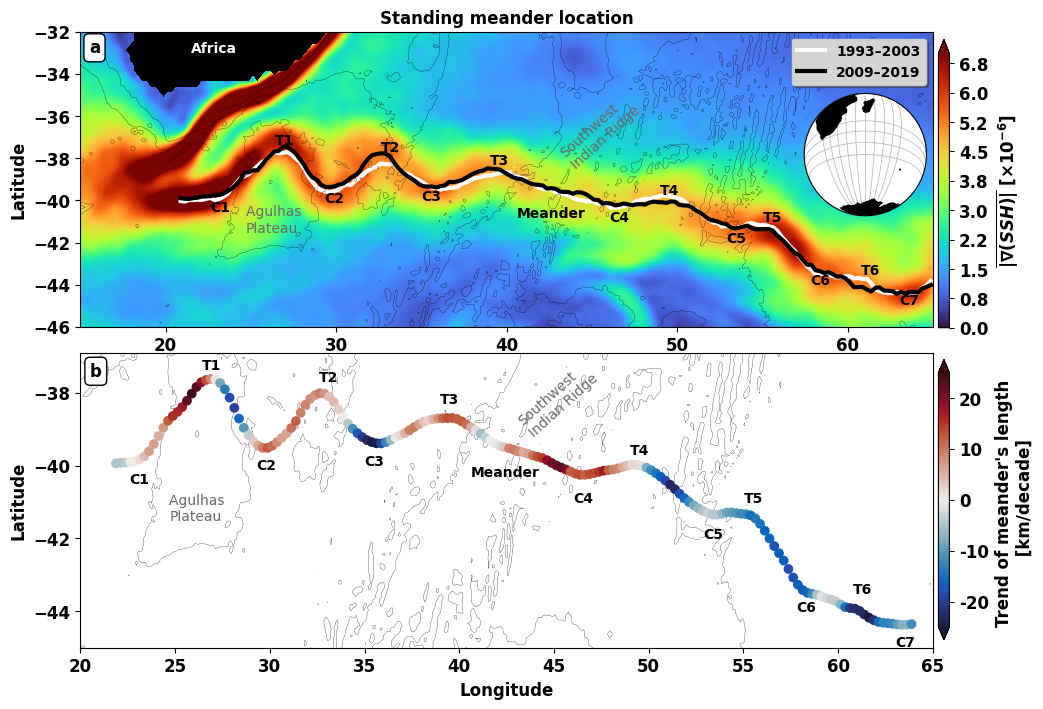

In [26]:
fig = plt.figure(figsize = (11,8))
extent = [14.99, 75.1, -50, -30.5]

ax = [fig.add_subplot(grd[:48,:]),
      fig.add_subplot(grd[52:,:])]

####################### FIGURE 1
cf1 = ax[0].contourf(lon, lat, _ADT_mean*1e6, np.arange(0,7.05,.05), cmap='turbo', extend='max')  
# ax[0].plot(lon_front, lat_front_mean, color = 'k', linewidth = 3)
ax[0].plot(lon_front, lat_front_1stDecade, color = 'w', linewidth = 3, label = '1993–2003')
ax[0].plot(lon_front, lat_front_2ndDecade, color = 'k', linewidth = 3, label = '2009–2019')
# ax[0].plot(lon_front, lat_front_mean, color = 'lime', linewidth = 2, label = '26-year mean')

####################################### Details
ax[0].legend(fontsize = 10, shadow = True, facecolor = 'lightgrey', loc = 'upper right')
# ax[0].set_xticklabels([])
ax[0].set_title('Standing meander location', fontsize = 12)
# ax[0].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
ax[0].annotate(text='a', color='k', xy=(15.5,-33), xycoords='data', bbox=props, fontsize = 12, zorder = 300)
ax[0].annotate(text='Africa', color='w', xy=(21.5,-33), xycoords='data', fontsize = 10, zorder = 300)
ax[0].patch.set_color('k')

####################### FIGURE 2
cf2 = ax[1].scatter(lon_meand[window:-window], lat_filt_mean[window:-window], c = slope_smth*12*10, cmap = cm.balance, vmin = -25, vmax = 25, zorder = 50)   

# Details
ax[1].set_xlabel('Longitude')
ax[1].annotate(text='b', color='k', xy=(20.5,-37.55), xycoords='data', bbox=props, fontsize = 12, zorder = 300)
for i in range(len(ax)): 
    ax[i].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='k', linewidths=.2)
    ax[i].set_ylabel('Latitude')

    ax[i].annotate(text='C1', color='k', xy=(22.6,-40.5), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T1', color='k', xy=(26.4,-37.35), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C2', color='k', xy=(29.3,-40.1), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T2', color='k', xy=(32.6,-37.7), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C3', color='k', xy=(35,-40), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T3', color='k', xy=(39,-38.3), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C4', color='k', xy=(46,-41), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T4', color='k', xy=(49,-39.7), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C5', color='k', xy=(52.9,-42), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T5', color='k', xy=(55,-41), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C6', color='k', xy=(57.8,-44), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T6', color='k', xy=(60.8,-43.5), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C7', color='k', xy=(63,-44.95), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='Agulhas \nPlateau', color='dimgrey', xy=(24.7,-41.5), xycoords='data', fontsize = 10, zorder = 300, fontweight = 'normal')
    ax[i].annotate(text='Meander', color='k', xy=(40.6,-40.8+i*.5), xycoords='data', fontsize = 10, zorder = 300, fontweight = 'bold')
    ax[i].annotate(text='Southwest\nIndian Ridge', color='dimgrey', xy=(43,-38.5-i*.7), rotation = 42, xycoords='data', fontsize = 10, zorder = 300, fontweight = 'normal')
# ax[0].annotate(text='Southwest', color='dimgrey', xy=(37,-43.2), rotation = 42, xycoords='data', fontsize = 10, zorder = 300, fontweight = 'normal')
# ax[0].annotate(text='Southwest\nIndian Ridge', color='dimgrey', xy=(43,-38.5), rotation = 42, xycoords='data', fontsize = 10, zorder = 300, fontweight = 'normal')
# ax[1].annotate(text='Southwest', color='dimgrey', xy=(38,-43), rotation = 42, xycoords='data', fontsize = 10, zorder = 300, fontweight = 'normal')
# ax[1].annotate(text='Indian Ridge', color='dimgrey', xy=(46,-39.1), rotation = 42, xycoords='data', fontsize = 10, zorder = 300, fontweight = 'normal')
ax[0].set_ylim(-46,-32)
ax[1].set_ylim(-45,-36.9)
ax[0].set_xlim(15,65) 
ax[1].set_xlim(20,65) 

## Colorbar
bar = plt.axes([0.905, 0.51, 0.01, 0.36])
cbar = plt.colorbar(cf1, cax = bar, format = '%.1f')  
cbar.set_label(r'$\overline{|\nabla(SSH)|}$ [$\times 10^{-6}$]') 

bar = plt.axes([0.905, 0.12, 0.01, 0.35])
cbar = plt.colorbar(cf2, cax = bar, extend = 'both', format = '%.0f')  
cbar.set_label("Trend of meander's length \n [km/decade]") 

####################### FIGURE MAP
ax = fig.add_subplot(grd[10:30,84:], projection=ccrs.NearsidePerspective(central_longitude=45, central_latitude=-45, 
                                                                        satellite_height=3000000, false_easting=0, 
                                                                        false_northing=0, globe=None))
ax.add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
gl = ax.gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.5)
gl.ylocator = mticker.FixedLocator(np.arange(-45, -25, 5))
gl.xlocator = mticker.FixedLocator(np.arange(20, 70, 5))

plt.savefig(path_fig + 'Fig1.jpg', dpi =300, bbox_inches = 'tight')

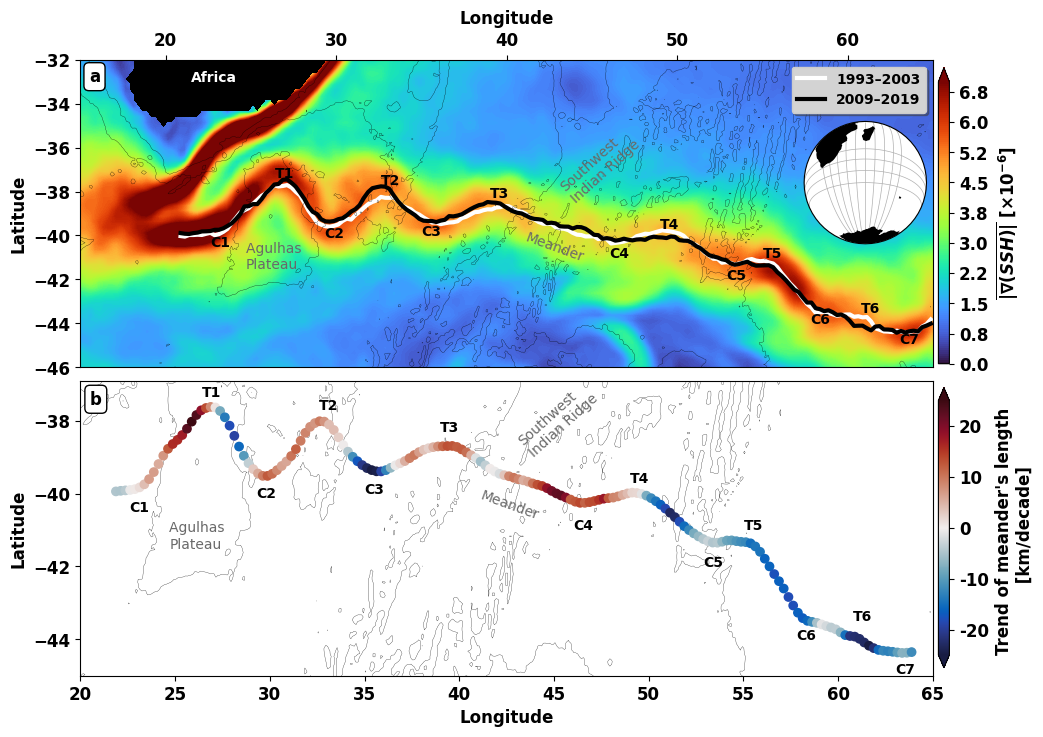

In [42]:
fig = plt.figure(figsize = (11,8))
extent = [14.99, 75.1, -50, -30.5]

ax = [fig.add_subplot(grd[:50,:]),
      fig.add_subplot(grd[52:,:])]

####################### FIGURE 1
cf1 = ax[0].contourf(lon, lat, _ADT_mean*1e6, np.arange(0,7.05,.05), cmap='turbo', extend='max')  
# ax[0].plot(lon_front, lat_front_mean, color = 'k', linewidth = 3)
ax[0].plot(lon_front, lat_front_1stDecade, color = 'w', linewidth = 3, label = '1993–2003')
ax[0].plot(lon_front, lat_front_2ndDecade, color = 'k', linewidth = 3, label = '2009–2019')
# ax[0].plot(lon_front, lat_front_mean, color = 'lime', linewidth = 2, label = '26-year mean')

####################################### Details
ax[0].legend(fontsize = 10, shadow = True, facecolor = 'lightgrey', loc = 'upper right')
# ax[0].set_xticklabels([])
ax[0].set_title('Longitude', fontsize = 12)
ax[0].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
ax[0].annotate(text='a', color='k', xy=(15.5,-33), xycoords='data', bbox=props, fontsize = 12, zorder = 300)
ax[0].annotate(text='Africa', color='w', xy=(21.5,-33), xycoords='data', fontsize = 10, zorder = 300)
ax[0].patch.set_color('k')

####################### FIGURE 2
cf2 = ax[1].scatter(lon_meand[window:-window], lat_filt_mean[window:-window], c = slope_smth*12*10, cmap = cm.balance, vmin = -25, vmax = 25, zorder = 50)   

# Details
ax[1].set_xlabel('Longitude')
ax[1].annotate(text='b', color='k', xy=(20.5,-37.55), xycoords='data', bbox=props, fontsize = 12, zorder = 300)
for i in range(len(ax)): 
    ax[i].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='k', linewidths=.2)
    ax[i].set_ylabel('Latitude')

    ax[i].annotate(text='C1', color='k', xy=(22.6,-40.5), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T1', color='k', xy=(26.4,-37.35), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C2', color='k', xy=(29.3,-40.1), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T2', color='k', xy=(32.6,-37.7), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C3', color='k', xy=(35,-40), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T3', color='k', xy=(39,-38.3), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C4', color='k', xy=(46,-41), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T4', color='k', xy=(49,-39.7), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C5', color='k', xy=(52.9,-42), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T5', color='k', xy=(55,-41), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C6', color='k', xy=(57.8,-44), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T6', color='k', xy=(60.8,-43.5), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C7', color='k', xy=(63,-44.95), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='Agulhas \nPlateau', color='dimgrey', xy=(24.7,-41.5), xycoords='data', fontsize = 10, zorder = 300, fontweight = 'normal')
    ax[i].annotate(text='Meander', color='dimgrey', xy=(41,-41.2+i*.5), rotation = -20, xycoords='data', fontsize = 10, zorder = 300, fontweight = 'normal')
    ax[i].annotate(text='Southwest\nIndian Ridge', color='dimgrey', xy=(43,-38.5-i*.5), rotation = 42, xycoords='data', fontsize = 10, zorder = 300, fontweight = 'normal')
# ax[0].annotate(text='Southwest', color='dimgrey', xy=(37,-43.2), rotation = 42, xycoords='data', fontsize = 10, zorder = 300, fontweight = 'normal')
# ax[0].annotate(text='Southwest\nIndian Ridge', color='dimgrey', xy=(43,-38.5), rotation = 42, xycoords='data', fontsize = 10, zorder = 300, fontweight = 'normal')
# ax[1].annotate(text='Southwest', color='dimgrey', xy=(38,-43), rotation = 42, xycoords='data', fontsize = 10, zorder = 300, fontweight = 'normal')
# ax[1].annotate(text='Indian Ridge', color='dimgrey', xy=(46,-39.1), rotation = 42, xycoords='data', fontsize = 10, zorder = 300, fontweight = 'normal')
ax[0].set_ylim(-46,-32)
ax[1].set_ylim(-45,-36.9)
ax[0].set_xlim(15,65) 
ax[1].set_xlim(20,65) 

## Colorbar
bar = plt.axes([0.905, 0.5, 0.01, 0.37])
cbar = plt.colorbar(cf1, cax = bar, format = '%.1f')  
cbar.set_label(r'$\overline{|\nabla(SSH)|}$ [$\times 10^{-6}$]') 

bar = plt.axes([0.905, 0.12, 0.01, 0.35])
cbar = plt.colorbar(cf2, cax = bar, extend = 'both', format = '%.0f')  
cbar.set_label("Trend of meander's length \n [km/decade]") 

####################### FIGURE MAP
ax = fig.add_subplot(grd[10:30,84:], projection=ccrs.NearsidePerspective(central_longitude=45, central_latitude=-45, 
                                                                        satellite_height=3000000, false_easting=0, 
                                                                        false_northing=0, globe=None))
ax.add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
gl = ax.gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.5)
gl.ylocator = mticker.FixedLocator(np.arange(-45, -25, 5))
gl.xlocator = mticker.FixedLocator(np.arange(20, 70, 5))

plt.savefig(path_fig + 'Fig1.jpg', dpi =300, bbox_inches = 'tight')

## Other version

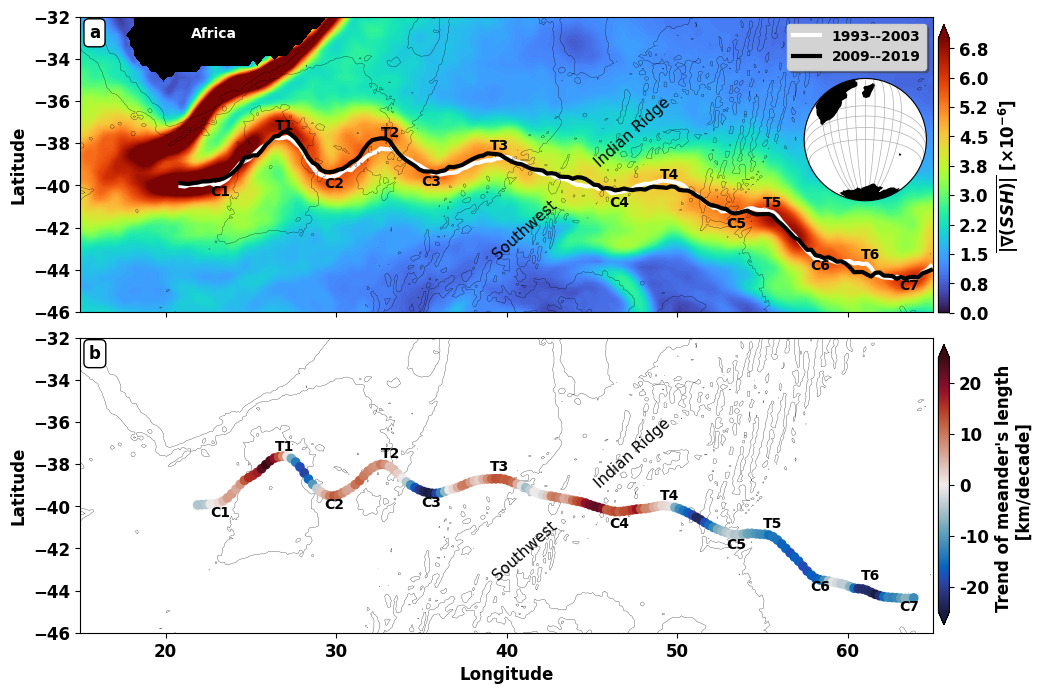

In [26]:
fig = plt.figure(figsize = (11,8))
extent = [14.99, 75.1, -50, -30.5]

ax = [fig.add_subplot(grd[:48,:]),
      fig.add_subplot(grd[52:,:])]

####################### FIGURE 1
cf1 = ax[0].contourf(lon, lat, _ADT_mean*1e6, np.arange(0,7.05,.05), cmap='turbo', extend='max')  
# ax[0].plot(lon_front, lat_front_mean, color = 'k', linewidth = 3)
ax[0].plot(lon_front, lat_front_1stDecade, color = 'w', linewidth = 3, label = '1993--2003')
ax[0].plot(lon_front, lat_front_2ndDecade, color = 'k', linewidth = 3, label = '2009--2019')
# ax[0].plot(lon_front, lat_front_mean, color = 'lime', linewidth = 2, label = '26-year mean')

####################################### Details
ax[0].legend(fontsize = 10, shadow = True, facecolor = 'lightgrey', loc = 'upper right')
ax[0].set_xticklabels([])
ax[0].annotate(text='a', color='k', xy=(15.5,-33), xycoords='data', bbox=props, fontsize = 12, zorder = 300)
ax[0].annotate(text='Africa', color='w', xy=(21.5,-33), xycoords='data', fontsize = 10, zorder = 300)
ax[0].patch.set_color('k')

####################### FIGURE 2
cf2 = ax[1].scatter(lon_meand[window:-window], lat_filt_mean[window:-window], c = slope_smth*12*10, cmap = cm.balance, vmin = -25, vmax = 25, zorder = 50)   

# Details
ax[1].set_xlabel('Longitude')
ax[1].annotate(text='b', color='k', xy=(15.5,-33), xycoords='data', bbox=props, fontsize = 12, zorder = 300)
for i in range(len(ax)): 
    ax[i].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='k', linewidths=.2)
    ax[i].set_ylabel('Latitude')
    ax[i].set_xlim(15,65)    
    ax[i].set_ylim(-46,-32)

    ax[i].annotate(text='C1', color='k', xy=(22.6,-40.5), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T1', color='k', xy=(26.4,-37.35), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C2', color='k', xy=(29.3,-40.1), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T2', color='k', xy=(32.6,-37.7), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C3', color='k', xy=(35,-40), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T3', color='k', xy=(39,-38.3), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C4', color='k', xy=(46,-41), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T4', color='k', xy=(49,-39.7), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C5', color='k', xy=(52.9,-42), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T5', color='k', xy=(55,-41), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C6', color='k', xy=(57.8,-44), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T6', color='k', xy=(60.8,-43.5), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C7', color='k', xy=(63,-44.95), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='Southwest', color='k', xy=(39,-43.5), rotation = 42, xycoords='data', fontsize = 11, zorder = 300, fontweight = 'normal')
    ax[i].annotate(text='Indian Ridge', color='k', xy=(45,-39.1), rotation = 42, xycoords='data', fontsize = 11, zorder = 300, fontweight = 'normal')
# ax[1].annotate(text='Southwest', color='k', xy=(39,-42), rotation = 42, xycoords='data', fontsize = 11, zorder = 300, fontweight = 'normal')
# ax[1].annotate(text='Indian Ridge', color='k', xy=(45,-39.1), rotation = 42, xycoords='data', fontsize = 11, zorder = 300, fontweight = 'normal')

## Colorbar
bar = plt.axes([0.905, 0.51, 0.01, 0.36])
cbar = plt.colorbar(cf1, cax = bar, format = '%.1f')  
cbar.set_label(r'$\overline{|\nabla(SSH)|}$ [$\times 10^{-6}$]') 

bar = plt.axes([0.905, 0.12, 0.01, 0.35])
cbar = plt.colorbar(cf2, cax = bar, extend = 'both', format = '%.0f')  
cbar.set_label("Trend of meander's length \n [km/decade]") 

####################### FIGURE MAP
ax = fig.add_subplot(grd[10:30,84:], projection=ccrs.NearsidePerspective(central_longitude=45, central_latitude=-45, 
                                                                        satellite_height=3000000, false_easting=0, 
                                                                        false_northing=0, globe=None))
ax.add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
gl = ax.gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.5)
gl.ylocator = mticker.FixedLocator(np.arange(-45, -25, 5))
gl.xlocator = mticker.FixedLocator(np.arange(20, 70, 5))

plt.savefig(path_fig + 'Fig1_v2.jpg', dpi =300, bbox_inches = 'tight')

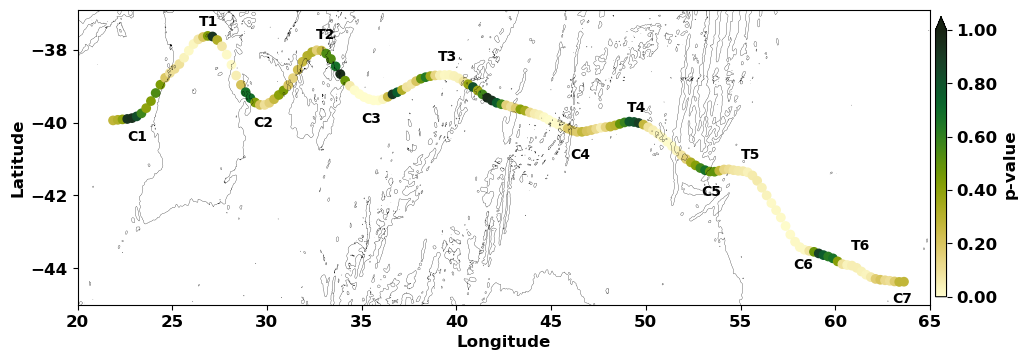

In [22]:
fig = plt.figure(figsize = (11,8))
extent = [14.99, 75.1, -50, -30.5]

ax = [fig.add_subplot(grd[52:,:])]

####################### FIGURE 2
cf2 = ax[0].scatter(lon_meand[window:-window], lat_filt_mean[window:-window], c = p_value_smth, cmap = cm.speed, vmin = 0, vmax = 1)   
ax[0].contour(bathy.lon, bathy.lat, bathy, levels=np.arange(0,8000,2000), colors='k', linewidths=.2)

# Details
# ax[0].annotate(text='b', color='k', xy=(20.5,-37.55), xycoords='data', bbox=props, fontsize = 12, zorder = 300)
ax[0].annotate(text='C1', color='k', xy=(22.6,-40.5), xycoords='data', fontsize = 10, zorder = 300)
ax[0].annotate(text='T1', color='k', xy=(26.4,-37.35), xycoords='data', fontsize = 10, zorder = 300)
ax[0].annotate(text='C2', color='k', xy=(29.3,-40.1), xycoords='data', fontsize = 10, zorder = 300)
ax[0].annotate(text='T2', color='k', xy=(32.6,-37.7), xycoords='data', fontsize = 10, zorder = 300)
ax[0].annotate(text='C3', color='k', xy=(35,-40), xycoords='data', fontsize = 10, zorder = 300)
ax[0].annotate(text='T3', color='k', xy=(39,-38.3), xycoords='data', fontsize = 10, zorder = 300)
ax[0].annotate(text='C4', color='k', xy=(46,-41), xycoords='data', fontsize = 10, zorder = 300)
ax[0].annotate(text='T4', color='k', xy=(49,-39.7), xycoords='data', fontsize = 10, zorder = 300)
ax[0].annotate(text='C5', color='k', xy=(52.9,-42), xycoords='data', fontsize = 10, zorder = 300)
ax[0].annotate(text='T5', color='k', xy=(55,-41), xycoords='data', fontsize = 10, zorder = 300)
ax[0].annotate(text='C6', color='k', xy=(57.8,-44), xycoords='data', fontsize = 10, zorder = 300)
ax[0].annotate(text='T6', color='k', xy=(60.8,-43.5), xycoords='data', fontsize = 10, zorder = 300)
ax[0].annotate(text='C7', color='k', xy=(63,-44.95), xycoords='data', fontsize = 10, zorder = 300)
# ax[0].annotate(text='Southwest', color='k', xy=(39,-42), rotation = 42, xycoords='data', fontsize = 11, zorder = 300, fontweight = 'normal')
# ax[0].annotate(text='Indian Ridge', color='k', xy=(45,-39.1), rotation = 42, xycoords='data', fontsize = 11, zorder = 300, fontweight = 'normal')

ax[0].set_ylabel('Latitude')
ax[0].set_xlabel('Longitude')
ax[0].set_xlim(20,65)
ax[0].set_ylim(-45,-36.9)

## Colorbar
bar = plt.axes([0.905, 0.12, 0.01, 0.35])
cbar = plt.colorbar(cf2, cax = bar, extend = 'max', format = '%.2f')  
cbar.set_label('p-value') 
plt.savefig(path_fig + 'Fig_S1.jpg', dpi =300, bbox_inches = 'tight')

## First draft

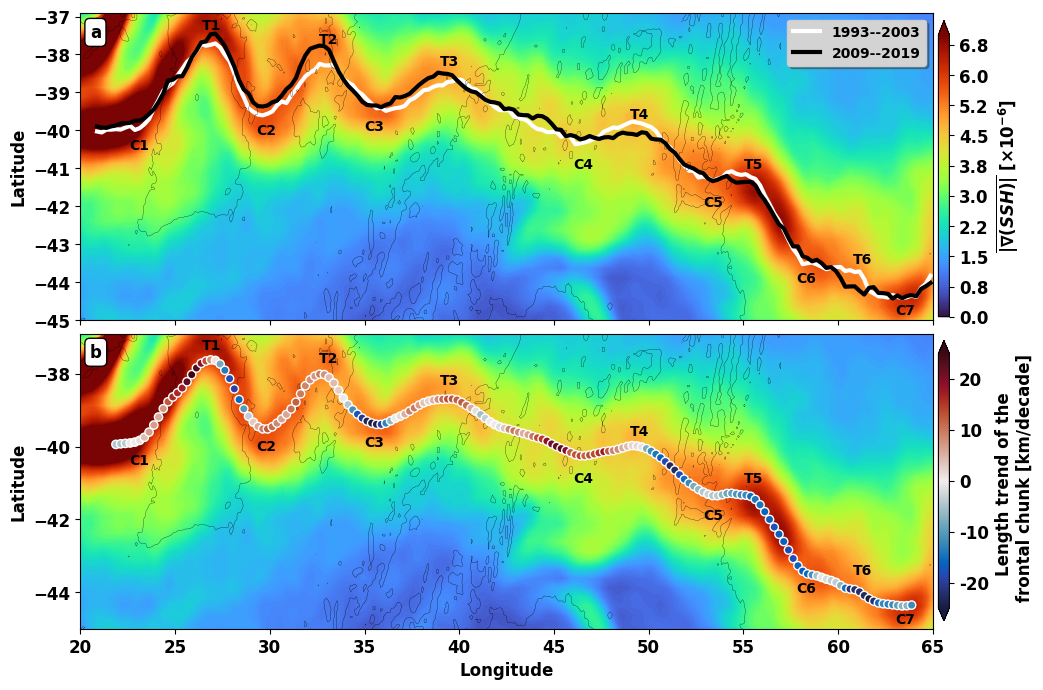

In [51]:
fig = plt.figure(figsize = (11,8))
extent = [14.99, 75.1, -50, -30.5]

ax = [fig.add_subplot(grd[:50,:]),
      fig.add_subplot(grd[52:,:])]

####################### FIGURE 1
# ax[0].plot(lon_front, lat_front_mean, color = 'k', linewidth = 3)
ax[0].plot(lon_front, lat_front_1stDecade, color = 'w', linewidth = 3, label = '1993--2003')
ax[0].plot(lon_front, lat_front_2ndDecade, color = 'k', linewidth = 3, label = '2009--2019')
# ax[0].plot(lon_front, lat_front_mean, color = 'lime', linewidth = 2, label = '26-year mean')

####################################### Details
ax[0].annotate(text='a', color='k', xy=(15.5,-32), xycoords='data', bbox=props, fontsize = 12, zorder = 300)
ax[0].legend(fontsize = 10, shadow = True, facecolor = 'lightgrey', loc = 'upper right')
ax[0].set_xticklabels([])
ax[0].annotate(text='a', color='k', xy=(20.5,-37.55), xycoords='data', bbox=props, fontsize = 12, zorder = 300)
# ax[0].set_ylim(-50, -30.5)
# ax[0].set_xlim(-14.99, 75.1)

####################### FIGURE 2
cf2 = ax[1].scatter(lon_meand[window:-window], lat_filt_mean[window:-window], c = slope_smth*12*10, cmap = cm.balance, vmin = -25, vmax = 25, edgecolor = 'w', zorder = 50)   

# Details
ax[1].set_xlabel('Longitude')
ax[1].annotate(text='b', color='k', xy=(20.5,-37.55), xycoords='data', bbox=props, fontsize = 12, zorder = 300)
for i in range(len(ax)):
    cf1 = ax[i].contourf(lon, lat, _ADT_mean*1e6, np.arange(0,7.05,.05), cmap='turbo', extend='max')   
    ax[i].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='k', linewidths=.2)
    ax[i].set_ylabel('Latitude')
    ax[i].set_ylim(-45,-36.9)
    ax[i].set_xlim(20,65)    

    ax[i].annotate(text='C1', color='k', xy=(22.6,-40.5), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T1', color='k', xy=(26.4,-37.35), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C2', color='k', xy=(29.3,-40.1), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T2', color='k', xy=(32.6,-37.7), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C3', color='k', xy=(35,-40), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T3', color='k', xy=(39,-38.3), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C4', color='k', xy=(46,-41), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T4', color='k', xy=(49,-39.7), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C5', color='k', xy=(52.9,-42), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T5', color='k', xy=(55,-41), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C6', color='k', xy=(57.8,-44), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='T6', color='k', xy=(60.8,-43.5), xycoords='data', fontsize = 10, zorder = 300)
    ax[i].annotate(text='C7', color='k', xy=(63,-44.85), xycoords='data', fontsize = 10, zorder = 300)

## Colorbar
bar = plt.axes([0.905, 0.5, 0.01, 0.37])
cbar = plt.colorbar(cf1, cax = bar, format = '%.1f')  
cbar.set_label(r'$\overline{|\nabla(SSH)|}$ [$\times 10^{-6}$]') 

bar = plt.axes([0.905, 0.12, 0.01, 0.35])
cbar = plt.colorbar(cf2, cax = bar, extend = 'both', format = '%.0f')  
cbar.set_label('Length trend of the \n frontal chunk [km/decade]') 
plt.savefig(path_fig + 'Fig2.jpg', dpi =300, bbox_inches = 'tight')